In [42]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import smarts_cerebellum.globals as gl

df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'patients_lme_DTI.tsv'), sep = '\t')
df['Week'] = df['week'].str.extract(r'(\d+)') # get numeric values
df['region_bilat'] = df['regionname'].str[:3]


df['side'] = 'ipsilesional'
is_cst=df['region_bilat'] == 'CST'
df.loc[is_cst & (df.regionname.str[-1] == 'L'), 'side'] = 'contralesional'
df.loc[~is_cst & (df.regionname.str[-1] == 'L'), 'side'] = 'contralesional'

# sort weeks!!
df['Week'] = df['Week'].astype(int)
df=df.sort_values('Week')


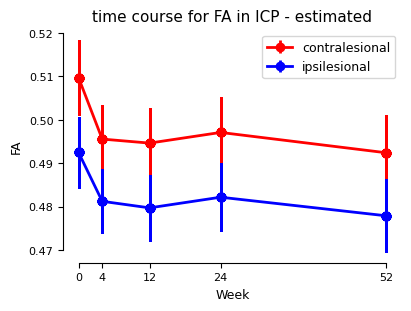

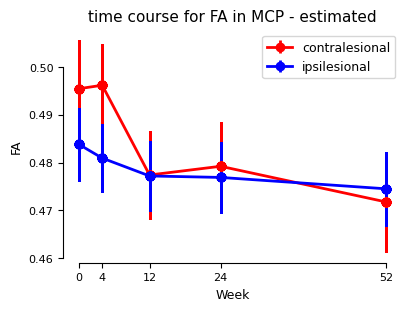

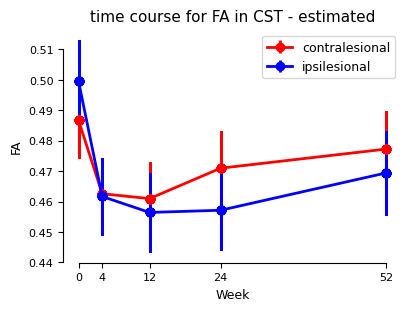

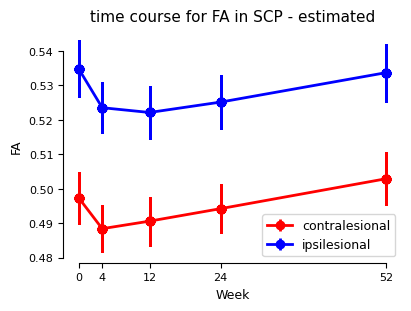

In [44]:
for r, region in enumerate(df.region_bilat.unique()):
    fig, ax = plt.subplots(figsize = (4,3), constrained_layout = True)

    ax.errorbar(x = 'Week', y = 'beta', yerr = 'se', data = df[(df.region_bilat == region) & (df.side == 'contralesional')], fmt = '-o', linewidth = 2, color = 'red', label = 'contralesional')
    ax.errorbar(x = 'Week', y = 'beta', yerr = 'se', data = df[(df.region_bilat == region) & (df.side == 'ipsilesional')], fmt = '-o', linewidth = 2, color = 'blue', label = 'ipsilesional')

    ax.legend()
    plt.ylabel("FA")
    plt.xlabel("Week")
    ax.set_xticks(gl.weeks)
    plt.title(f"time course for FA in {region} - estimated")
    sns.despine(trim = True)
    plt.show()
